# NB06 — Phase 1 Correction: clay_confined_subsurface H3 IR-side

**Goal**: The `clay_confined_subsurface` project (PR #231, merged) used K07811, K17324, K17323 as iron-reduction markers for its H3 (porewater-vs-rock-attached signature) test. Those K-numbers turn out to be TMAO reductase, glycerol ABC transport, and glycerol permease respectively — not iron reduction. KEGG has no canonical KO for the Geobacter omcS / Shewanella mtr operon. The clay project's IR-side findings need to be redone with proper multi-heme cytochrome detection.

**Method (revised in plan v1.2 after NB01 confirmed PF14537 silently absent)**: triple-signal multi-heme cytochrome detector:
1. PFAM PF02085 (Cytochrom_CIII, multi-heme c-type) presence per genome from `bakta_pfam_domains`
2. PFAM PF22678 (Cytochrom_c_NrfB-like, multi-heme nitrite reductase) presence per genome
3. CXXCH heme-binding motif counting per protein in `gene_cluster.faa_sequence` — protein with ≥4 CXXCH motifs = multi-heme candidate

Genome `has_multiheme_cytochrome` = (≥1 PF02085) OR (≥1 PF22678) OR (≥1 cluster with ≥4 CXXCH motifs).

**Inputs**: `../clay_confined_subsurface/data/cohort_assignments.tsv`, `../clay_confined_subsurface/data/baseline_features.parquet`, `kbase_ke_pangenome.{bakta_pfam_domains, gene, gene_genecluster_junction, gene_cluster}`.

**Output**: `data/clay_h3_ir_corrected.tsv`, `figures/clay_h3_ir_corrected.png`. The correction commit on the `clay_confined_subsurface` project's branch is handled separately (cherry-pick or correction PR).

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pyspark.sql import functions as F

try:
    spark
except NameError:
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)
CLAY_DATA = Path('../../clay_confined_subsurface/data')

# clay project has TWO feature files: genome_features.parquet (anchor) + baseline_features.parquet
clay_anchor_features = pd.read_parquet(CLAY_DATA / 'genome_features.parquet')
clay_baseline_features = pd.read_parquet(CLAY_DATA / 'baseline_features.parquet')
all_clay = pd.concat([clay_anchor_features, clay_baseline_features], ignore_index=True, sort=False)
all_clay = all_clay[all_clay['genome_id'].notna()].copy()
all_clay = all_clay.drop_duplicates(subset='genome_id').reset_index(drop=True)
print(f'clay total cohort: {len(all_clay)}')
print(all_clay['cohort_class'].value_counts())


clay total cohort: 210
cohort_class
soil_baseline     149
anchor_shallow     30
unclassified       20
anchor_deep         9
excluded            2
Name: count, dtype: int64


## 1. Pull PF02085 + PF22678 (and PF14537 for confirmation) per genome

In [2]:
clay_genomes = all_clay['genome_id'].tolist()
spark.createDataFrame([(g,) for g in clay_genomes], ['genome_id']).createOrReplaceTempView('clay_genomes_v')

pfam_df = spark.sql("""
    SELECT g.genome_id, p.pfam_id, COUNT(DISTINCT p.gene_cluster_id) AS n_clusters
    FROM clay_genomes_v c
    JOIN kbase_ke_pangenome.gene g ON g.genome_id = c.genome_id
    JOIN kbase_ke_pangenome.gene_genecluster_junction j ON g.gene_id = j.gene_id
    JOIN kbase_ke_pangenome.bakta_pfam_domains p ON p.gene_cluster_id = j.gene_cluster_id
    WHERE p.pfam_id LIKE 'PF02085%' OR p.pfam_id LIKE 'PF22678%' OR p.pfam_id LIKE 'PF14537%'
    GROUP BY g.genome_id, p.pfam_id
""").toPandas()
print(f'pfam hits: {len(pfam_df)}')
pfam_pivot = pfam_df.assign(pfam_short=pfam_df['pfam_id'].str.split('.').str[0]).pivot_table(
    index='genome_id', columns='pfam_short', values='n_clusters', aggfunc='sum', fill_value=0).reset_index()
print(pfam_pivot.head())
print(f'\ngenomes with any PF02085/PF22678 hit: {((pfam_pivot.iloc[:, 1:]>0).any(axis=1)).sum()}')

pfam hits: 3
pfam_short           genome_id  PF02085  PF22678
0           GB_GCA_003556645.1        1        0
1           GB_GCA_022567875.1        1        1

genomes with any PF02085/PF22678 hit: 2


## 2. CXXCH heme-binding motif counting in gene_cluster.faa_sequence

In [3]:
# Heavy step. Need to: (a) get clusters per clay-cohort genome, (b) join faa_sequence,
# (c) count CXXCH motifs per protein in Spark, (d) aggregate per-genome.
# CXXCH = 'C..CH' regex. Use Spark size(regexp_extract_all(seq, 'C..CH')) for counting.

motif_df = spark.sql("""
    WITH clay_clusters AS (
      SELECT DISTINCT g.genome_id, j.gene_cluster_id
      FROM clay_genomes_v c
      JOIN kbase_ke_pangenome.gene g ON g.genome_id = c.genome_id
      JOIN kbase_ke_pangenome.gene_genecluster_junction j ON g.gene_id = j.gene_id
    ),
    cluster_seq AS (
      SELECT cc.genome_id, cc.gene_cluster_id, gc.faa_sequence,
             SIZE(regexp_extract_all(gc.faa_sequence, 'C..CH', 0)) AS n_cxxch
      FROM clay_clusters cc
      JOIN kbase_ke_pangenome.gene_cluster gc
        ON gc.gene_cluster_id = cc.gene_cluster_id
      WHERE gc.faa_sequence IS NOT NULL AND gc.is_cluster_rep = TRUE
    )
    SELECT genome_id,
           SUM(CASE WHEN n_cxxch >= 4 THEN 1 ELSE 0 END) AS n_multiheme_clusters,
           MAX(n_cxxch) AS max_cxxch
    FROM cluster_seq
    GROUP BY genome_id
""").toPandas()
print(f'genomes with motif data: {len(motif_df)}')
print(motif_df['n_multiheme_clusters'].describe())
print('\ngenomes with >=1 multi-heme cluster (>=4 CXXCH motifs):',
      (motif_df['n_multiheme_clusters'] >= 1).sum())

genomes with motif data: 210
count    210.000000
mean       1.309524
std        3.131016
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       27.000000
Name: n_multiheme_clusters, dtype: float64

genomes with >=1 multi-heme cluster (>=4 CXXCH motifs): 81


## 3. Combine into corrected has_multiheme_cytochrome boolean

In [4]:
ir = all_clay[['genome_id','cohort_class','sub_cohort','compartment','depth_class','tax_phylum','tax_genus']].copy()
ir = ir.merge(pfam_pivot, on='genome_id', how='left')
ir = ir.merge(motif_df, on='genome_id', how='left')
for c in ['PF02085','PF22678','PF14537']:
    if c in ir.columns:
        ir[c] = ir[c].fillna(0).astype(int)
    else:
        ir[c] = 0
ir['n_multiheme_clusters'] = ir['n_multiheme_clusters'].fillna(0).astype(int)
ir['has_multiheme_cyt'] = (ir['PF02085'] >= 1) | (ir['PF22678'] >= 1) | (ir['n_multiheme_clusters'] >= 1)

# Original clay project IR_complete (for direct contrast)
ir = ir.merge(all_clay[['genome_id','IR_complete']].rename(columns={'IR_complete':'IR_complete_original'}), on='genome_id', how='left')
ir['IR_complete_original'] = ir['IR_complete_original'].fillna(False)
ir['IR_complete_original'] = ir['IR_complete_original'].fillna(False)

# Per-cohort breakdown
summary = ir.groupby('cohort_class').agg(
    n=('genome_id','count'),
    PF02085_n=('PF02085', lambda x: (x>=1).sum()),
    PF22678_n=('PF22678', lambda x: (x>=1).sum()),
    PF14537_n=('PF14537', lambda x: (x>=1).sum()),
    multiheme_motif_n=('n_multiheme_clusters', lambda x: (x>=1).sum()),
    multiheme_cyt_n=('has_multiheme_cyt', 'sum'),
    multiheme_cyt_rate=('has_multiheme_cyt', 'mean'),
    IR_complete_orig_rate=('IR_complete_original', 'mean'),
).round(3)
summary

,n,PF02085_n,PF22678_n,PF14537_n,multiheme_motif_n,multiheme_cyt_n,multiheme_cyt_rate,IR_complete_orig_rate
cohort_class,,,,,,,,
anchor_deep,9,0,0,0,5,5,0.556,0.111
anchor_shallow,30,0,0,0,12,12,0.400,0.500
excluded,2,0,0,0,0,0,0.000,0.000
soil_baseline,149,2,1,0,61,61,0.409,0.201
unclassified,20,0,0,0,3,3,0.150,0.250


## 4. Re-test clay H3: corrected SR/IR signature

Use the same clay-project framework: anchor_deep is SR-rich/IR-poor (Bagnoud porewater), anchor_shallow is SR-poor/IR-rich (Mitzscherling rock-attached comparison). Replace the wrong IR_complete with `has_multiheme_cyt`.

In [5]:
# pairwise Fisher on has_multiheme_cyt across cohort_class
rows = []
for grp_a, grp_b in [('anchor_deep','anchor_shallow'),
                     ('anchor_deep','soil_baseline'),
                     ('anchor_shallow','soil_baseline')]:
    a = ir[ir['cohort_class']==grp_a]['has_multiheme_cyt']
    b = ir[ir['cohort_class']==grp_b]['has_multiheme_cyt']
    if len(a) < 3 or len(b) < 3:
        continue
    table = [[int(a.sum()), len(a)-int(a.sum())], [int(b.sum()), len(b)-int(b.sum())]]
    odds, p = stats.fisher_exact(table, alternative='two-sided')
    rows.append({'comparison': f'{grp_a} vs {grp_b}',
                 'n_a': len(a), 'pos_a': int(a.sum()),
                 'n_b': len(b), 'pos_b': int(b.sum()),
                 'rate_a': a.mean(), 'rate_b': b.mean(),
                 'odds_ratio': odds, 'p_value': p})
fisher_df = pd.DataFrame(rows).round(4)
fisher_df

,comparison,n_a,pos_a,n_b,pos_b,rate_a,rate_b,odds_ratio,p_value
0,anchor_deep vs anchor_shallow,9,5,30,12,0.5556,0.4000,1.8750,0.4648
1,anchor_deep vs soil_baseline,9,5,149,61,0.5556,0.4094,1.8033,0.4923
2,anchor_shallow vs soil_baseline,30,12,149,61,0.4000,0.4094,0.9617,1.0000


In [6]:
# Original-vs-corrected comparison (the headline of this correction)
compare = ir.groupby('cohort_class').agg(
    n=('genome_id','count'),
    IR_complete_original_rate=('IR_complete_original','mean'),
    has_multiheme_cyt_corrected_rate=('has_multiheme_cyt','mean'),
).round(3)
compare

,n,IR_complete_original_rate,has_multiheme_cyt_corrected_rate
cohort_class,,,
anchor_deep,9,0.111,0.556
anchor_shallow,30,0.500,0.400
excluded,2,0.000,0.000
soil_baseline,149,0.201,0.409
unclassified,20,0.250,0.150


## 5. Visualization

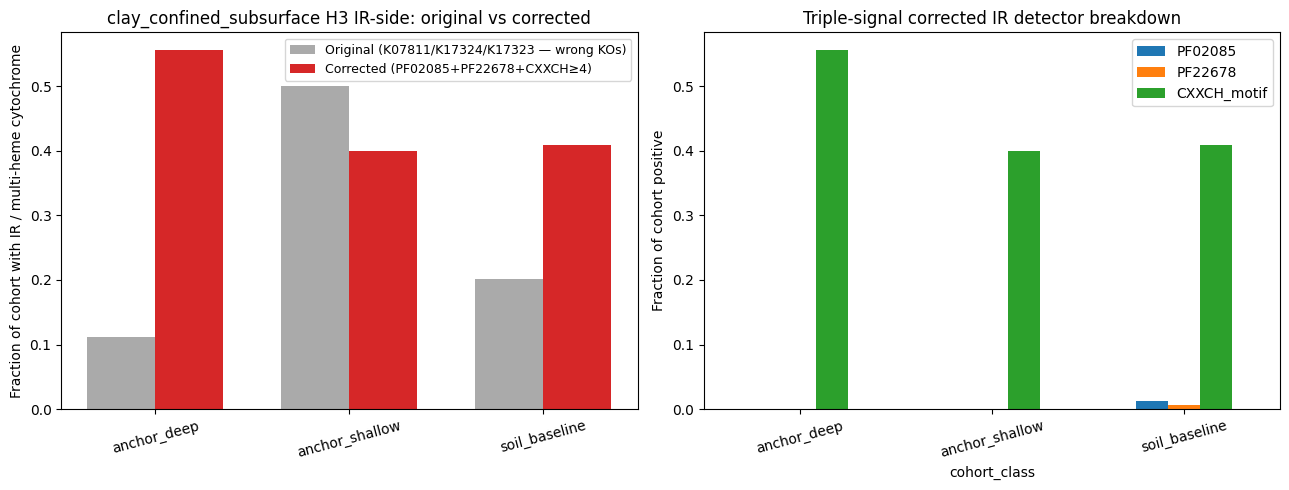

saved: ../figures/clay_h3_ir_corrected.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ['anchor_deep', 'anchor_shallow', 'soil_baseline']

# Original vs corrected IR rates per cohort
data = ir[ir['cohort_class'].isin(order)].copy()
rates_orig = data.groupby('cohort_class')['IR_complete_original'].mean().reindex(order)
rates_corr = data.groupby('cohort_class')['has_multiheme_cyt'].mean().reindex(order)
x = np.arange(len(order)); w = 0.35
axes[0].bar(x - w/2, rates_orig.values, w, label='Original (K07811/K17324/K17323 — wrong KOs)', color='#aaaaaa')
axes[0].bar(x + w/2, rates_corr.values, w, label='Corrected (PF02085+PF22678+CXXCH≥4)', color='#d62728')
axes[0].set_xticks(x); axes[0].set_xticklabels(order, rotation=15)
axes[0].set_ylabel('Fraction of cohort with IR / multi-heme cytochrome')
axes[0].set_title('clay_confined_subsurface H3 IR-side: original vs corrected')
axes[0].legend(loc='upper right', fontsize=9)

# Triple-signal breakdown for corrected
comp_rates = data.groupby('cohort_class').agg(
    PF02085=('PF02085', lambda x: (x>=1).mean()),
    PF22678=('PF22678', lambda x: (x>=1).mean()),
    CXXCH_motif=('n_multiheme_clusters', lambda x: (x>=1).mean()),
).reindex(order)
comp_rates.plot(kind='bar', ax=axes[1])
axes[1].set_xticklabels(order, rotation=15)
axes[1].set_ylabel('Fraction of cohort positive')
axes[1].set_title('Triple-signal corrected IR detector breakdown')
axes[1].legend()

plt.tight_layout()
out_fig = FIG_DIR / 'clay_h3_ir_corrected.png'
plt.savefig(out_fig, dpi=140, bbox_inches='tight'); plt.show()
print(f'saved: {out_fig}')

In [8]:
ir.to_csv(DATA_DIR / 'clay_h3_ir_corrected.tsv', sep='\t', index=False)
fisher_df.to_csv(DATA_DIR / 'clay_h3_ir_corrected_fisher.tsv', sep='\t', index=False)
compare.to_csv(DATA_DIR / 'clay_h3_ir_orig_vs_corrected.tsv', sep='\t')
print('saved clay_h3_ir_corrected*.tsv')
print('\n=== HEADLINE: clay H3 IR — original vs corrected ===')
print(compare)
print('\n=== corrected pairwise Fisher ===')
print(fisher_df)

saved clay_h3_ir_corrected*.tsv

=== HEADLINE: clay H3 IR — original vs corrected ===
                  n  IR_complete_original_rate  \
cohort_class                                     
anchor_deep       9                      0.111   
anchor_shallow   30                      0.500   
excluded          2                      0.000   
soil_baseline   149                      0.201   
unclassified     20                      0.250   

                has_multiheme_cyt_corrected_rate  
cohort_class                                      
anchor_deep                                0.556  
anchor_shallow                             0.400  
excluded                                   0.000  
soil_baseline                              0.409  
unclassified                               0.150  

=== corrected pairwise Fisher ===
                        comparison  n_a  pos_a  n_b  pos_b  rate_a  rate_b  \
0    anchor_deep vs anchor_shallow    9      5   30     12  0.5556  0.4000   
1     anchor_de